In [ ]:
# --- Cell 0: Imports ---
from ecg_monitor.pipeline import (
    build_df_all, get_train_test_split,
    FEATURE_COLS, DS1_RECORDS, DS2_RECORDS,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.interpolate import CubicSpline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_sample_weight

print("Imports loaded.")

In [ ]:
# --- Cell 1: Build dataset ---
# Signal processing functions now imported from ecg_pipeline.
df_all, pca = build_df_all()

In [4]:
# --- Cell 3: Session-level aggregation functions ---

def compute_hrv_frequency(nn_intervals_s):
    """Compute HRV frequency-domain metrics from N-N intervals.
    
    Args:
        nn_intervals_s: array of N-N intervals in seconds
    
    Returns:
        dict with vlf_power_s2, lf_power_s2, hf_power_s2, lf_hf_ratio, total_power_s2
    """
    result = {
        'vlf_power_s2': np.nan, 'lf_power_s2': np.nan, 'hf_power_s2': np.nan,
        'lf_hf_ratio': np.nan, 'total_power_s2': np.nan,
    }
    
    if len(nn_intervals_s) < 30:
        return result
    
    # Cumulative time axis from N-N intervals
    t_nn = np.cumsum(nn_intervals_s)
    t_nn = t_nn - t_nn[0]  # start at 0
    
    # Cubic spline interpolation to uniform 4 Hz
    fs_interp = 4.0
    t_uniform = np.arange(t_nn[0], t_nn[-1], 1.0 / fs_interp)
    
    if len(t_uniform) < 64:
        return result
    
    cs = CubicSpline(t_nn, nn_intervals_s)
    nn_uniform = cs(t_uniform)
    
    # Linear detrend
    nn_uniform = nn_uniform - np.polyval(np.polyfit(t_uniform, nn_uniform, 1), t_uniform)
    
    # Welch PSD
    nperseg = min(256, len(nn_uniform))
    freqs, psd = welch(nn_uniform, fs=fs_interp, nperseg=nperseg, noverlap=nperseg // 2, window='hann')
    
    # Band integration
    vlf_mask = (freqs >= 0.003) & (freqs < 0.04)
    lf_mask = (freqs >= 0.04) & (freqs < 0.15)
    hf_mask = (freqs >= 0.15) & (freqs < 0.4)
    
    vlf_power = np.trapezoid(psd[vlf_mask], freqs[vlf_mask]) if vlf_mask.sum() > 1 else np.nan
    lf_power = np.trapezoid(psd[lf_mask], freqs[lf_mask]) if lf_mask.sum() > 1 else np.nan
    hf_power = np.trapezoid(psd[hf_mask], freqs[hf_mask]) if hf_mask.sum() > 1 else np.nan
    
    result['vlf_power_s2'] = vlf_power
    result['lf_power_s2'] = lf_power
    result['hf_power_s2'] = hf_power
    result['lf_hf_ratio'] = lf_power / hf_power if hf_power and hf_power > 0 else np.nan
    result['total_power_s2'] = np.trapezoid(psd[(freqs >= 0.003) & (freqs < 0.4)],
                                             freqs[(freqs >= 0.003) & (freqs < 0.4)])
    
    return result


def compute_session_metrics(df_session, fs=360, label_col='clinical_label'):
    """Compute all session-level metrics from a single record's beat DataFrame.
    
    Args:
        df_session: DataFrame with per-beat features for one record
        fs: sampling frequency
        label_col: column name for beat labels ('clinical_label' or 'predicted_label')
    
    Returns:
        dict of session metrics
    """
    total = len(df_session)
    labels = df_session[label_col]
    
    n_count = (labels == 'N').sum()
    s_count = (labels == 'S').sum()
    v_count = (labels == 'V').sum()
    
    # --- Ectopic burden ---
    pvc_burden_pct = 100.0 * v_count / total if total > 0 else 0.0
    sve_burden_pct = 100.0 * s_count / total if total > 0 else 0.0
    ectopic_burden_pct = pvc_burden_pct + sve_burden_pct
    
    # Rate-normalized: MIT-BIH records are ~30 min
    # Estimate session duration from first to last beat sample_idx
    if 'sample_idx' in df_session.columns and total >= 2:
        duration_s = (df_session['sample_idx'].iloc[-1] - df_session['sample_idx'].iloc[0]) / fs
    else:
        duration_s = total * df_session['rr_prev'].median()  # fallback
    duration_h = duration_s / 3600.0
    
    pvc_per_hour = v_count / duration_h if duration_h > 0 else 0.0
    sve_per_hour = s_count / duration_h if duration_h > 0 else 0.0
    
    # --- N-N intervals for HRV ---
    # A valid N-N interval: current beat is N AND previous beat is also N
    prev_label = labels.shift(1)
    nn_mask = (labels == 'N') & (prev_label == 'N')
    nn_intervals = df_session.loc[nn_mask, 'rr_prev'].values
    
    # Physiological filter: 0.3s < NN < 2.0s (30-200 bpm)
    nn_intervals = nn_intervals[(nn_intervals > 0.3) & (nn_intervals < 2.0)]
    
    # --- HRV time-domain ---
    if len(nn_intervals) >= 10:
        mean_nn_s = np.mean(nn_intervals)
        mean_hr_bpm = 60.0 / mean_nn_s
        sdnn_ms = np.std(nn_intervals, ddof=1) * 1000.0
        
        nn_diffs = np.diff(nn_intervals)
        rmssd_ms = np.sqrt(np.mean(nn_diffs ** 2)) * 1000.0
        pnn50_pct = 100.0 * np.sum(np.abs(nn_diffs) > 0.050) / len(nn_diffs)
    else:
        mean_hr_bpm = np.nan
        sdnn_ms = np.nan
        rmssd_ms = np.nan
        pnn50_pct = np.nan
    
    # --- HRV frequency-domain ---
    freq_metrics = compute_hrv_frequency(nn_intervals)
    
    # --- Morphology (N beats only) ---
    n_beats = df_session[labels == 'N']
    if len(n_beats) > 0:
        mean_qrs_width_ms = n_beats['qrs_width_ms'].mean()
        std_qrs_width_ms = n_beats['qrs_width_ms'].std()
        mean_r_amplitude = n_beats['r_amplitude'].mean()
    else:
        mean_qrs_width_ms = np.nan
        std_qrs_width_ms = np.nan
        mean_r_amplitude = np.nan
    
    # --- Pauses (all R-R intervals, not just N-N) ---
    all_rr = df_session['rr_prev'].values
    pause_count_2s = int(np.sum(all_rr > 2.0))
    pause_count_3s = int(np.sum(all_rr > 3.0))
    max_rr_interval_s = float(np.max(all_rr)) if len(all_rr) > 0 else np.nan
    
    return {
        # Counts
        'total_beats': total,
        'n_count': int(n_count),
        's_count': int(s_count),
        'v_count': int(v_count),
        'duration_min': duration_s / 60.0,
        # Ectopic burden
        'pvc_burden_pct': pvc_burden_pct,
        'sve_burden_pct': sve_burden_pct,
        'ectopic_burden_pct': ectopic_burden_pct,
        'pvc_per_hour': pvc_per_hour,
        'sve_per_hour': sve_per_hour,
        # HRV time-domain
        'mean_hr_bpm': mean_hr_bpm,
        'sdnn_ms': sdnn_ms,
        'rmssd_ms': rmssd_ms,
        'pnn50_pct': pnn50_pct,
        'nn_count': len(nn_intervals),
        # HRV frequency-domain
        **freq_metrics,
        # Morphology
        'mean_qrs_width_ms': mean_qrs_width_ms,
        'std_qrs_width_ms': std_qrs_width_ms,
        'mean_r_amplitude': mean_r_amplitude,
        # Pauses
        'pause_count_2s': pause_count_2s,
        'pause_count_3s': pause_count_3s,
        'max_rr_interval_s': max_rr_interval_s,
    }

print("Session aggregation functions defined.")

Session aggregation functions defined.


In [5]:
# --- Cell 4: Aggregate all 44 records into df_sessions (ground truth labels) ---

session_rows = []
for rec_id, df_rec in df_all.groupby('record'):
    metrics = compute_session_metrics(df_rec, fs=360, label_col='clinical_label')
    metrics['record'] = rec_id
    session_rows.append(metrics)

df_sessions = pd.DataFrame(session_rows).set_index('record').sort_index()

print(f"Session metrics computed for {len(df_sessions)} records\n")

# Display key metrics
display_cols = ['total_beats', 'duration_min', 'pvc_burden_pct', 'sve_burden_pct',
                'mean_hr_bpm', 'sdnn_ms', 'rmssd_ms', 'pnn50_pct',
                'lf_hf_ratio', 'pause_count_2s']
print(df_sessions[display_cols].round(1).to_string())

print(f"\n--- Summary statistics ---")
print(df_sessions[['pvc_burden_pct', 'sve_burden_pct', 'mean_hr_bpm', 'sdnn_ms',
                    'rmssd_ms', 'lf_hf_ratio']].describe().round(2).to_string())

Session metrics computed for 44 records

        total_beats  duration_min  pvc_burden_pct  sve_burden_pct  mean_hr_bpm  sdnn_ms  rmssd_ms  pnn50_pct  lf_hf_ratio  pause_count_2s
record                                                                                                                                   
100            2271          30.1             0.0             1.5         75.5     35.9      27.8        6.6          0.1               0
101            1860          30.1             0.0             0.2         62.0     67.8      41.1       21.2          0.5               0
103            2081          30.1             0.0             0.1         69.3     50.1      40.5       11.6          0.4               0
105            2526          30.1             1.6             0.0         86.6     58.6      68.8        7.3          0.2               0
106            2024          30.0            25.6             0.0         63.5    123.7     104.4       40.1          0.6          

In [6]:
# --- Cell 5: Dual-label comparison — train GB, predict DS2, compare session metrics ---

# Train GB classifier (same hyperparams as main notebook)
train_mask = df_all['record'].isin(DS1_RECORDS)
test_mask = df_all['record'].isin(DS2_RECORDS)

X_train = df_all.loc[train_mask, FEATURE_COLS].values
y_train = df_all.loc[train_mask, 'clinical_label'].values
X_test = df_all.loc[test_mask, FEATURE_COLS].values
y_test = df_all.loc[test_mask, 'clinical_label'].values

sample_weights = compute_sample_weight('balanced', y_train)

clf_gb = HistGradientBoostingClassifier(
    max_iter=300, max_depth=6, learning_rate=0.1,
    min_samples_leaf=20, l2_regularization=1.0, random_state=42,
)
clf_gb.fit(X_train, y_train, sample_weight=sample_weights)

# Predict on DS2 records
y_pred = clf_gb.predict(X_test)
y_proba = clf_gb.predict_proba(X_test)
class_order = clf_gb.classes_  # ['N', 'S', 'V']
s_idx = list(class_order).index('S')
v_idx = list(class_order).index('V')

print("=== GB Classifier on DS2 (same as main notebook) ===\n")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

# Attach predicted labels and probabilities to df_all for DS2 records
df_all.loc[test_mask, 'predicted_label'] = y_pred
df_all.loc[test_mask, 'prob_S'] = y_proba[:, s_idx]
df_all.loc[test_mask, 'prob_V'] = y_proba[:, v_idx]

# Compute session metrics with predicted labels (DS2 only)
pred_session_rows = []
for rec_id, df_rec in df_all[test_mask].groupby('record'):
    metrics = compute_session_metrics(df_rec, fs=360, label_col='predicted_label')
    
    # Probability-based SVE/PVC burden estimates
    metrics['sve_burden_prob_pct'] = 100.0 * df_rec['prob_S'].sum() / len(df_rec)
    metrics['pvc_burden_prob_pct'] = 100.0 * df_rec['prob_V'].sum() / len(df_rec)
    
    metrics['record'] = rec_id
    pred_session_rows.append(metrics)

df_sessions_pred = pd.DataFrame(pred_session_rows).set_index('record').sort_index()

# True session metrics for DS2 only
df_sessions_true = df_sessions.loc[df_sessions.index.isin(DS2_RECORDS)].copy()

print(f"\nDS2 records: {len(df_sessions_true)} true, {len(df_sessions_pred)} predicted")

=== GB Classifier on DS2 (same as main notebook) ===

              precision    recall  f1-score   support

           N      0.962     0.973     0.967     43885
           S      0.313     0.175     0.225      1769
           V      0.846     0.916     0.880      3572

    accuracy                          0.940     49226
   macro avg      0.707     0.688     0.691     49226
weighted avg      0.930     0.940     0.934     49226


DS2 records: 22 true, 22 predicted


In [7]:
# --- Cell 6: Error propagation analysis — true vs predicted session metrics ---

# Per-metric error for DS2 records
error_metrics = ['pvc_burden_pct', 'sve_burden_pct', 'mean_hr_bpm', 'sdnn_ms', 'rmssd_ms',
                 'pnn50_pct', 'lf_hf_ratio', 'mean_qrs_width_ms']

print("=== Per-record error: predicted - true (DS2 records) ===\n")
print(f"{'Record':<8}", end='')
for m in ['pvc_%', 'sve_%', 'HR', 'SDNN', 'RMSSD']:
    print(f"{m:>10}", end='')
print()
print("-" * 58)

errors = {}
for m in error_metrics:
    errors[m] = df_sessions_pred[m] - df_sessions_true[m]

for rec_id in df_sessions_true.index:
    print(f"{rec_id:<8}", end='')
    for m, short in zip(error_metrics[:5], ['pvc_%', 'sve_%', 'HR', 'SDNN', 'RMSSD']):
        val = errors[m].get(rec_id, np.nan)
        print(f"{val:>+10.2f}", end='')
    print()

print(f"\n--- Error summary (predicted - true) ---")
print(f"{'Metric':<25} {'Mean':>10} {'Median':>10} {'MAE':>10} {'Max|Err|':>10}")
print("-" * 65)
for m in error_metrics:
    e = errors[m].dropna()
    if len(e) > 0:
        print(f"{m:<25} {e.mean():>+10.3f} {e.median():>+10.3f} {e.abs().mean():>10.3f} {e.abs().max():>10.3f}")

# Probability-based SVE burden comparison
print(f"\n--- SVE burden estimation methods (DS2 records) ---")
print(f"{'Record':<8} {'True':>10} {'Hard':>10} {'Prob':>10} {'Hard err':>10} {'Prob err':>10}")
print("-" * 58)
for rec_id in df_sessions_true.index:
    true_val = df_sessions_true.loc[rec_id, 'sve_burden_pct']
    hard_val = df_sessions_pred.loc[rec_id, 'sve_burden_pct']
    prob_val = df_sessions_pred.loc[rec_id, 'sve_burden_prob_pct']
    print(f"{rec_id:<8} {true_val:>10.2f} {hard_val:>10.2f} {prob_val:>10.2f} "
          f"{hard_val - true_val:>+10.2f} {prob_val - true_val:>+10.2f}")

# Aggregate comparison
sve_true = df_sessions_true['sve_burden_pct']
sve_hard = df_sessions_pred['sve_burden_pct']
sve_prob = df_sessions_pred['sve_burden_prob_pct']
print(f"\nSVE burden MAE — hard labels: {(sve_hard - sve_true).abs().mean():.3f}%")
print(f"SVE burden MAE — prob-based:  {(sve_prob - sve_true).abs().mean():.3f}%")

=== Per-record error: predicted - true (DS2 records) ===

Record       pvc_%     sve_%        HR      SDNN     RMSSD
----------------------------------------------------------
100          +0.00     -0.04     -0.00     +0.22     +0.98
103          +0.00     +0.10     -0.07     -3.29     -5.42
105          +3.52     +0.00     -0.39     -2.47     -2.87
111          +1.04     +0.00     -0.04     -1.04     -2.46
113          +0.00     +1.90     +0.02     -3.65     -2.08
117          +0.07     +0.07     -0.01     -0.95     -2.24
121          +0.16     +0.05     -0.11     -3.76     -5.14
123          +0.00     +0.40     -0.02     -0.67     +0.50
200          -1.05     +0.31     -0.04     +8.75    +21.34
202          +8.86     +1.64     -4.65    -16.20    -15.31
210          -0.30     +2.05     +0.11     +3.28     +4.94
212          +0.00     +0.07     -0.01     -0.09     -0.46
213          -5.54     +2.89     +0.03     +0.36     +0.93
214          -1.11     +0.36     -0.05    +25.58    +63.4

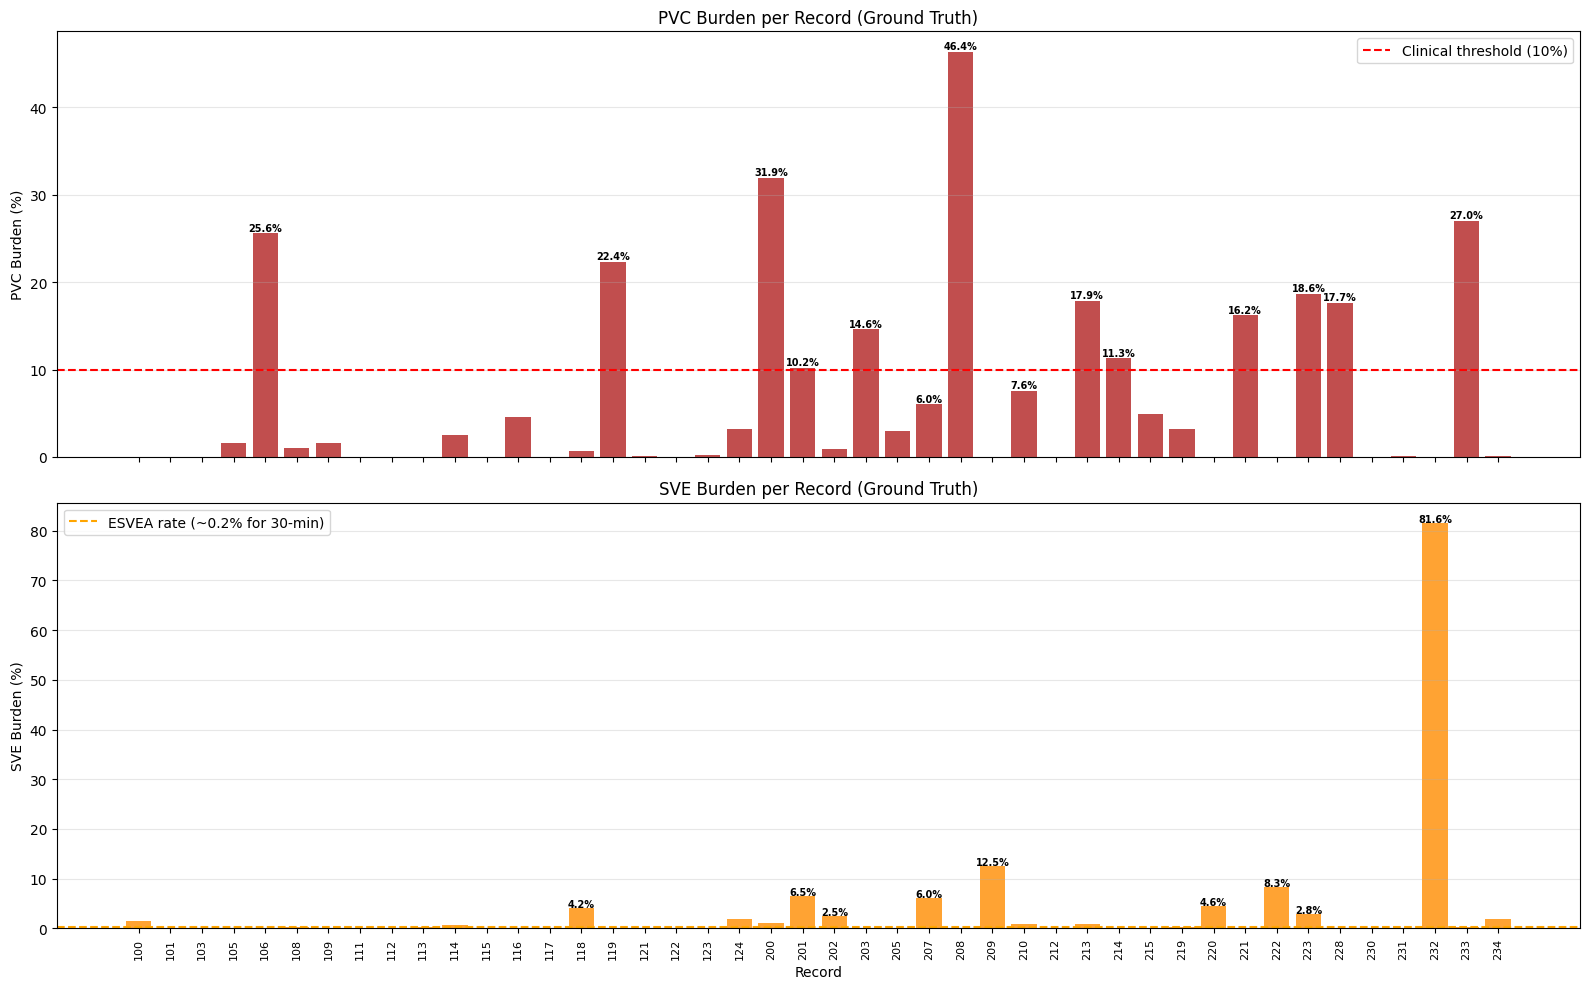

In [8]:
# --- Cell 7: Visualizations — ectopic burden bar charts ---

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

records = df_sessions.index.tolist()
x = np.arange(len(records))

# PVC burden
ax = axes[0]
bars = ax.bar(x, df_sessions['pvc_burden_pct'], color='firebrick', alpha=0.8)
ax.axhline(10, color='red', linestyle='--', linewidth=1.5, label='Clinical threshold (10%)')
ax.set_ylabel('PVC Burden (%)')
ax.set_title('PVC Burden per Record (Ground Truth)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
# Label high-PVC records
for i, rec in enumerate(records):
    val = df_sessions.loc[rec, 'pvc_burden_pct']
    if val > 5:
        ax.text(i, val + 0.3, f"{val:.1f}%", ha='center', fontsize=7, fontweight='bold')

# SVE burden
ax = axes[1]
ax.bar(x, df_sessions['sve_burden_pct'], color='darkorange', alpha=0.8)
# ESVEA threshold: >218 PACs per 24h. For 30-min session: 218/48 ≈ 4.5 per session
# Convert to percentage: 4.5/mean_beats * 100
mean_beats = df_sessions['total_beats'].mean()
esvea_pct = 100.0 * (218 / 48) / mean_beats
ax.axhline(esvea_pct, color='orange', linestyle='--', linewidth=1.5,
           label=f'ESVEA rate (~{esvea_pct:.1f}% for 30-min)')
ax.set_ylabel('SVE Burden (%)')
ax.set_title('SVE Burden per Record (Ground Truth)')
ax.set_xticks(x)
ax.set_xticklabels(records, rotation=90, fontsize=8)
ax.set_xlabel('Record')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for i, rec in enumerate(records):
    val = df_sessions.loc[rec, 'sve_burden_pct']
    if val > 2:
        ax.text(i, val + 0.2, f"{val:.1f}%", ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

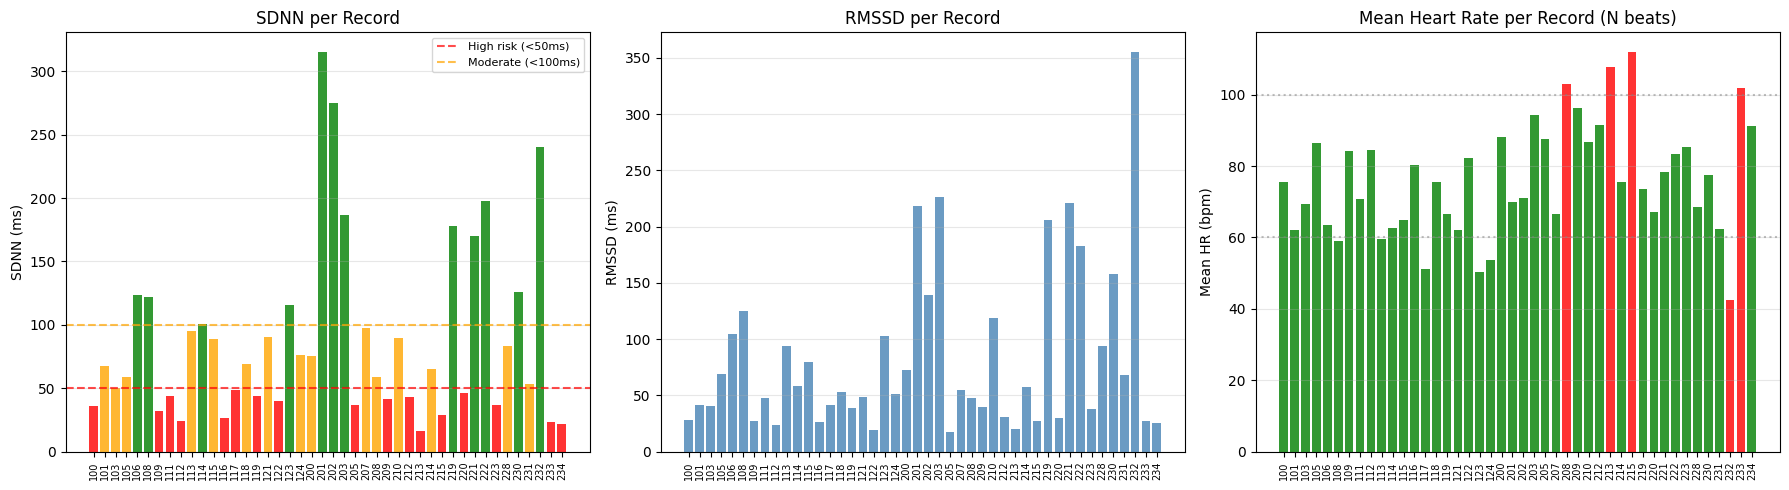

In [9]:
# --- Cell 8: SDNN distribution + HRV metrics ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SDNN bar chart color-coded by risk
ax = axes[0]
sdnn_vals = df_sessions['sdnn_ms'].dropna()
sdnn_colors = []
for v in sdnn_vals:
    if v < 50:
        sdnn_colors.append('red')       # High risk
    elif v < 100:
        sdnn_colors.append('orange')    # Moderate risk
    else:
        sdnn_colors.append('green')     # Normal
ax.bar(range(len(sdnn_vals)), sdnn_vals.values, color=sdnn_colors, alpha=0.8)
ax.set_xticks(range(len(sdnn_vals)))
ax.set_xticklabels(sdnn_vals.index, rotation=90, fontsize=7)
ax.set_ylabel('SDNN (ms)')
ax.set_title('SDNN per Record')
ax.axhline(50, color='red', linestyle='--', alpha=0.7, label='High risk (<50ms)')
ax.axhline(100, color='orange', linestyle='--', alpha=0.7, label='Moderate (<100ms)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# RMSSD
ax = axes[1]
rmssd_vals = df_sessions['rmssd_ms'].dropna()
ax.bar(range(len(rmssd_vals)), rmssd_vals.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(rmssd_vals)))
ax.set_xticklabels(rmssd_vals.index, rotation=90, fontsize=7)
ax.set_ylabel('RMSSD (ms)')
ax.set_title('RMSSD per Record')
ax.grid(True, alpha=0.3, axis='y')

# Mean HR
ax = axes[2]
hr_vals = df_sessions['mean_hr_bpm'].dropna()
hr_colors = ['red' if v > 100 or v < 50 else 'green' for v in hr_vals]
ax.bar(range(len(hr_vals)), hr_vals.values, color=hr_colors, alpha=0.8)
ax.set_xticks(range(len(hr_vals)))
ax.set_xticklabels(hr_vals.index, rotation=90, fontsize=7)
ax.set_ylabel('Mean HR (bpm)')
ax.set_title('Mean Heart Rate per Record (N beats)')
ax.axhline(60, color='gray', linestyle=':', alpha=0.5)
ax.axhline(100, color='gray', linestyle=':', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

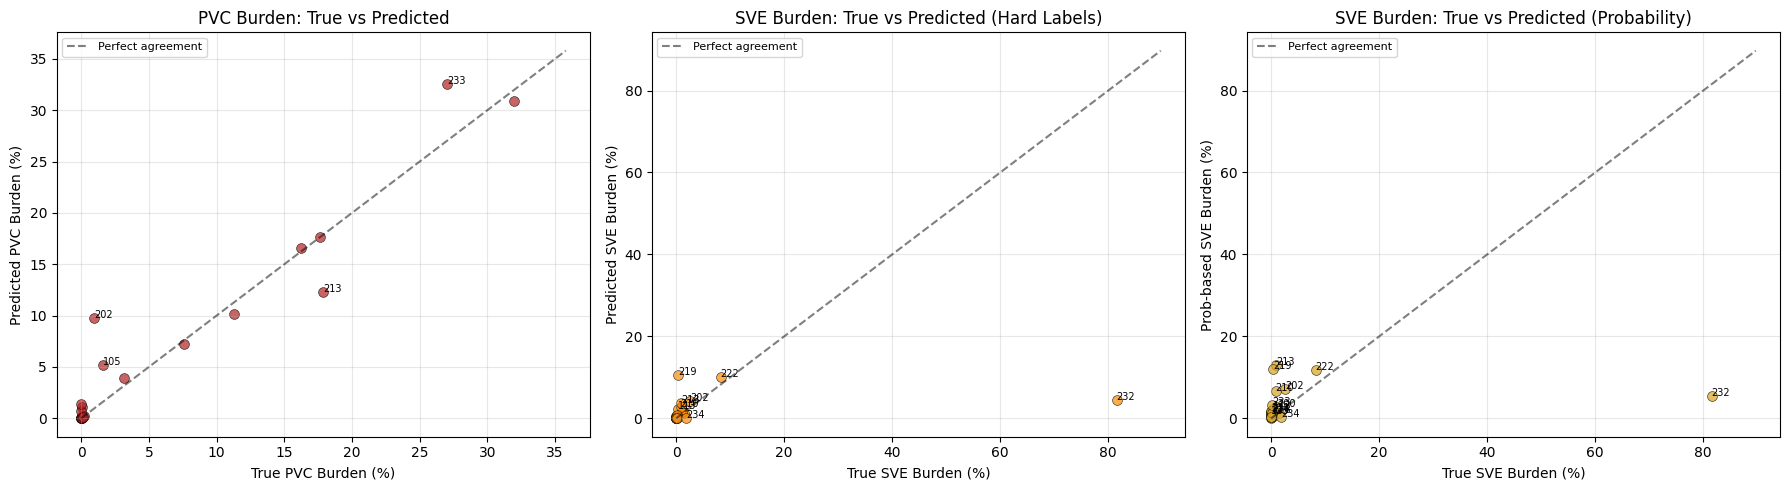

=== Error propagation summary (DS2 records) ===

  PVC burden           MAE=1.381  R2=0.921
  SVE burden (hard)    MAE=4.644  R2=0.034
  Mean HR              MAE=1.784  R2=0.852
  SDNN                 MAE=8.290  R2=0.932
  SVE burden (prob)    MAE=5.902  R2=0.017


In [10]:
# --- Cell 9: Error propagation scatter — true vs predicted burden (DS2) ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PVC burden
ax = axes[0]
true_pvc = df_sessions_true['pvc_burden_pct']
pred_pvc = df_sessions_pred['pvc_burden_pct']
max_val = max(true_pvc.max(), pred_pvc.max()) * 1.1
ax.scatter(true_pvc, pred_pvc, c='firebrick', s=50, alpha=0.7, edgecolors='black', linewidths=0.5)
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect agreement')
ax.set_xlabel('True PVC Burden (%)')
ax.set_ylabel('Predicted PVC Burden (%)')
ax.set_title('PVC Burden: True vs Predicted')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
# Annotate outliers
for rec_id in df_sessions_true.index:
    t, p = true_pvc[rec_id], pred_pvc[rec_id]
    if abs(t - p) > 2:
        ax.annotate(rec_id, (t, p), fontsize=7, ha='left')

# SVE burden — hard labels
ax = axes[1]
true_sve = df_sessions_true['sve_burden_pct']
pred_sve_hard = df_sessions_pred['sve_burden_pct']
max_val = max(true_sve.max(), pred_sve_hard.max()) * 1.1
ax.scatter(true_sve, pred_sve_hard, c='darkorange', s=50, alpha=0.7, edgecolors='black', linewidths=0.5)
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect agreement')
ax.set_xlabel('True SVE Burden (%)')
ax.set_ylabel('Predicted SVE Burden (%)')
ax.set_title('SVE Burden: True vs Predicted (Hard Labels)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
for rec_id in df_sessions_true.index:
    t, p = true_sve[rec_id], pred_sve_hard[rec_id]
    if abs(t - p) > 1:
        ax.annotate(rec_id, (t, p), fontsize=7, ha='left')

# SVE burden — probability-based
ax = axes[2]
pred_sve_prob = df_sessions_pred['sve_burden_prob_pct']
max_val = max(true_sve.max(), pred_sve_prob.max()) * 1.1
ax.scatter(true_sve, pred_sve_prob, c='goldenrod', s=50, alpha=0.7, edgecolors='black', linewidths=0.5)
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect agreement')
ax.set_xlabel('True SVE Burden (%)')
ax.set_ylabel('Prob-based SVE Burden (%)')
ax.set_title('SVE Burden: True vs Predicted (Probability)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
for rec_id in df_sessions_true.index:
    t, p = true_sve[rec_id], pred_sve_prob[rec_id]
    if abs(t - p) > 1:
        ax.annotate(rec_id, (t, p), fontsize=7, ha='left')

plt.tight_layout()
plt.show()

# Summary stats
from sklearn.metrics import mean_absolute_error, r2_score
print("=== Error propagation summary (DS2 records) ===\n")
for name, true_col, pred_col in [
    ('PVC burden', 'pvc_burden_pct', 'pvc_burden_pct'),
    ('SVE burden (hard)', 'sve_burden_pct', 'sve_burden_pct'),
    ('Mean HR', 'mean_hr_bpm', 'mean_hr_bpm'),
    ('SDNN', 'sdnn_ms', 'sdnn_ms'),
]:
    t = df_sessions_true[true_col].dropna()
    p = df_sessions_pred[pred_col].reindex(t.index).dropna()
    common = t.index.intersection(p.index)
    if len(common) > 1:
        mae = mean_absolute_error(t[common], p[common])
        r2 = r2_score(t[common], p[common])
        print(f"  {name:<20s} MAE={mae:.3f}  R2={r2:.3f}")

# SVE probability-based
t = df_sessions_true['sve_burden_pct'].dropna()
p = df_sessions_pred['sve_burden_prob_pct'].reindex(t.index).dropna()
common = t.index.intersection(p.index)
mae = mean_absolute_error(t[common], p[common])
r2 = r2_score(t[common], p[common])
print(f"  {'SVE burden (prob)':<20s} MAE={mae:.3f}  R2={r2:.3f}")

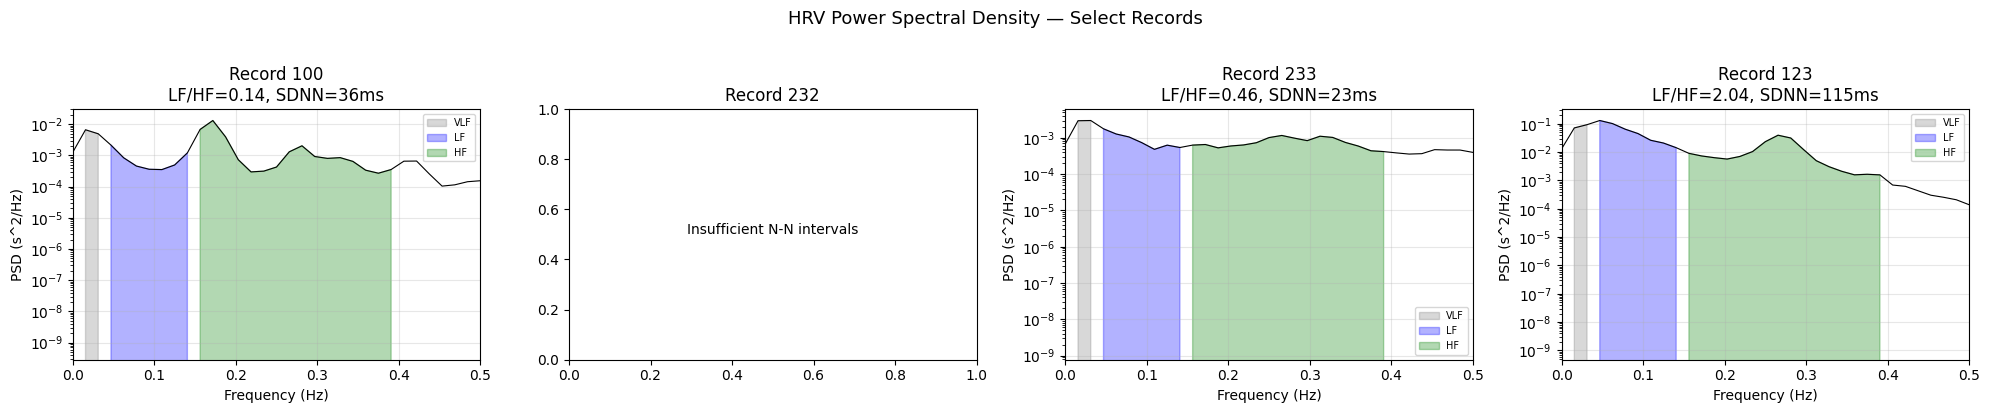

In [11]:
# --- Cell 10: HRV frequency-domain PSD plots (select records) ---

# Pick 4 records with varied profiles: normal, high PVC, high SVE, bradycardia
example_records = ['100', '232', '233', '123']  # Normal, high SVE, high PVC, slow HR
available = [r for r in example_records if r in df_all['record'].values]

fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4))
if len(available) == 1:
    axes = [axes]

for ax, rec_id in zip(axes, available):
    df_rec = df_all[df_all['record'] == rec_id]
    labels = df_rec['clinical_label']
    prev_label = labels.shift(1)
    nn_mask = (labels == 'N') & (prev_label == 'N')
    nn_intervals = df_rec.loc[nn_mask, 'rr_prev'].values
    nn_intervals = nn_intervals[(nn_intervals > 0.3) & (nn_intervals < 2.0)]
    
    if len(nn_intervals) < 30:
        ax.text(0.5, 0.5, 'Insufficient N-N intervals', transform=ax.transAxes, ha='center')
        ax.set_title(f'Record {rec_id}')
        continue
    
    t_nn = np.cumsum(nn_intervals) - nn_intervals[0]
    fs_interp = 4.0
    t_uniform = np.arange(t_nn[0], t_nn[-1], 1.0 / fs_interp)
    cs = CubicSpline(t_nn, nn_intervals)
    nn_uniform = cs(t_uniform)
    nn_uniform = nn_uniform - np.polyval(np.polyfit(t_uniform, nn_uniform, 1), t_uniform)
    
    nperseg = min(256, len(nn_uniform))
    freqs, psd = welch(nn_uniform, fs=fs_interp, nperseg=nperseg, noverlap=nperseg // 2, window='hann')
    
    ax.semilogy(freqs, psd, 'k-', linewidth=0.8)
    
    # Shade bands
    vlf_mask = (freqs >= 0.003) & (freqs < 0.04)
    lf_mask = (freqs >= 0.04) & (freqs < 0.15)
    hf_mask = (freqs >= 0.15) & (freqs < 0.4)
    
    ax.fill_between(freqs[vlf_mask], psd[vlf_mask], alpha=0.3, color='gray', label='VLF')
    ax.fill_between(freqs[lf_mask], psd[lf_mask], alpha=0.3, color='blue', label='LF')
    ax.fill_between(freqs[hf_mask], psd[hf_mask], alpha=0.3, color='green', label='HF')
    
    metrics = df_sessions.loc[rec_id]
    ax.set_title(f'Record {rec_id}\nLF/HF={metrics["lf_hf_ratio"]:.2f}, SDNN={metrics["sdnn_ms"]:.0f}ms')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (s^2/Hz)')
    ax.set_xlim(0, 0.5)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('HRV Power Spectral Density — Select Records', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# --- Cell 11: Clinical alert simulation — true vs predicted labels ---

# Define alert thresholds
PVC_THRESHOLD_PCT = 10.0    # PVC burden > 10% -> cardiomyopathy risk
SDNN_THRESHOLD_MS = 50.0    # SDNN < 50ms -> high cardiovascular risk
HR_HIGH_THRESHOLD = 100.0   # Mean HR > 100 bpm -> tachycardia
HR_LOW_THRESHOLD = 50.0     # Mean HR < 50 bpm -> bradycardia
PAUSE_THRESHOLD = 2.0       # Any pause > 2s

def compute_alerts(df_sess):
    alerts = {}
    alerts['pvc_high'] = set(df_sess[df_sess['pvc_burden_pct'] > PVC_THRESHOLD_PCT].index)
    alerts['sdnn_low'] = set(df_sess[df_sess['sdnn_ms'] < SDNN_THRESHOLD_MS].index)
    alerts['hr_high'] = set(df_sess[df_sess['mean_hr_bpm'] > HR_HIGH_THRESHOLD].index)
    alerts['hr_low'] = set(df_sess[df_sess['mean_hr_bpm'] < HR_LOW_THRESHOLD].index)
    alerts['pauses'] = set(df_sess[df_sess['pause_count_2s'] > 0].index)
    return alerts

# Only compare DS2 records (where we have predictions)
alerts_true = compute_alerts(df_sessions_true)
alerts_pred = compute_alerts(df_sessions_pred)

print("=== Clinical Alert Simulation (DS2 records) ===\n")
print(f"{'Alert':<20} {'True':>6} {'Pred':>6} {'Correct':>8} {'Missed':>8} {'False':>8}")
print("-" * 56)

for alert_name in ['pvc_high', 'sdnn_low', 'hr_high', 'hr_low', 'pauses']:
    true_set = alerts_true[alert_name]
    pred_set = alerts_pred[alert_name]
    correct = len(true_set & pred_set)
    missed = len(true_set - pred_set)
    false_pos = len(pred_set - true_set)
    print(f"{alert_name:<20} {len(true_set):>6} {len(pred_set):>6} {correct:>8} {missed:>8} {false_pos:>8}")
    if missed > 0:
        print(f"  {'Missed records:':<18} {sorted(true_set - pred_set)}")
    if false_pos > 0:
        print(f"  {'False alerts:':<18} {sorted(pred_set - true_set)}")

# Overall alert accuracy
all_true = set()
all_pred = set()
for v in alerts_true.values():
    all_true |= v
for v in alerts_pred.values():
    all_pred |= v

print(f"\n--- Overall (any alert) ---")
print(f"Records with true alerts:  {len(all_true)}/{len(df_sessions_true)}")
print(f"Records with pred alerts:  {len(all_pred)}/{len(df_sessions_pred)}")
print(f"Correctly alerted:         {len(all_true & all_pred)}")
print(f"Missed (no alert when needed): {len(all_true - all_pred)}")
print(f"False alerts:              {len(all_pred - all_true)}")

=== Clinical Alert Simulation (DS2 records) ===

Alert                  True   Pred  Correct   Missed    False
--------------------------------------------------------
pvc_high                  6      6        6        0        0
sdnn_low                  7      9        7        0        2
  False alerts:      ['103', '231']
hr_high                   2      2        2        0        0
hr_low                    1      0        0        1        0
  Missed records:    ['232']
pauses                    1      1        1        0        0

--- Overall (any alert) ---
Records with true alerts:  12/22
Records with pred alerts:  14/22
Correctly alerted:         12
Missed (no alert when needed): 0
False alerts:              2


In [13]:
# --- Cell 12: Validation checks ---

print("=== Validation ===\n")

# 1. Cross-check PVC burden against raw label counts
print("1. PVC burden cross-check (top 10 by PVC burden):")
true_counts = df_all.groupby('record')['clinical_label'].value_counts().unstack(fill_value=0)
true_counts['pvc_pct_check'] = 100.0 * true_counts.get('V', 0) / true_counts.sum(axis=1)
comparison = pd.DataFrame({
    'session_pvc': df_sessions['pvc_burden_pct'],
    'direct_pvc': true_counts['pvc_pct_check'],
})
comparison['diff'] = (comparison['session_pvc'] - comparison['direct_pvc']).abs()
print(comparison.nlargest(10, 'session_pvc').round(3).to_string())
print(f"Max discrepancy: {comparison['diff'].max():.6f}%\n")

# 2. SDNN range check (expect 20-250ms for 30-min recordings)
sdnn = df_sessions['sdnn_ms'].dropna()
print(f"2. SDNN range: {sdnn.min():.1f} - {sdnn.max():.1f} ms")
out_of_range = sdnn[(sdnn < 20) | (sdnn > 250)]
if len(out_of_range) > 0:
    print(f"   WARNING: {len(out_of_range)} records outside 20-250ms range:")
    print(f"   {out_of_range.to_dict()}")
else:
    print("   All records within expected 20-250ms range")

# 3. RMSSD range check (expect 10-100ms)
rmssd = df_sessions['rmssd_ms'].dropna()
print(f"\n3. RMSSD range: {rmssd.min():.1f} - {rmssd.max():.1f} ms")
out_of_range = rmssd[(rmssd < 5) | (rmssd > 200)]
if len(out_of_range) > 0:
    print(f"   Note: {len(out_of_range)} records outside typical 10-100ms range")
else:
    print("   All records within expected range")

# 4. Known high-PVC records should show high PVC burden
print(f"\n4. High-PVC records check:")
high_pvc_records = ['200', '208', '233']
for rec in high_pvc_records:
    if rec in df_sessions.index:
        pvc = df_sessions.loc[rec, 'pvc_burden_pct']
        v_count = df_sessions.loc[rec, 'v_count']
        print(f"   Record {rec}: PVC burden = {pvc:.1f}%, V count = {v_count}")

# 5. Mean HR consistency: session metric vs hr_inst mean for N beats
print(f"\n5. Mean HR consistency check (session metric vs hr_inst mean):")
hr_check = []
for rec_id, df_rec in df_all.groupby('record'):
    n_beats = df_rec[df_rec['clinical_label'] == 'N']
    if len(n_beats) > 0:
        hr_from_inst = n_beats['hr_inst'].mean()
        hr_from_session = df_sessions.loc[rec_id, 'mean_hr_bpm']
        hr_check.append({'record': rec_id, 'hr_inst': hr_from_inst, 'hr_session': hr_from_session,
                         'diff': abs(hr_from_inst - hr_from_session)})

hr_check_df = pd.DataFrame(hr_check).set_index('record')
print(f"   Mean absolute difference: {hr_check_df['diff'].mean():.2f} bpm")
print(f"   Max difference: {hr_check_df['diff'].max():.2f} bpm (record {hr_check_df['diff'].idxmax()})")
print(f"   Note: session HR uses N-N intervals only; hr_inst uses all preceding intervals")

# 6. DataFrame shape check
print(f"\n6. df_sessions shape: {df_sessions.shape}")
nan_counts = df_sessions.isna().sum()
nan_cols = nan_counts[nan_counts > 0]
if len(nan_cols) > 0:
    print(f"   Columns with NaN values:")
    for col, count in nan_cols.items():
        print(f"     {col}: {count}/{len(df_sessions)} records")
else:
    print("   No NaN values")

print("\nValidation complete.")

=== Validation ===

1. PVC burden cross-check (top 10 by PVC burden):
        session_pvc  direct_pvc  diff
record                               
208          46.371      46.371   0.0
200          31.940      31.940   0.0
233          27.028      27.028   0.0
106          25.593      25.593   0.0
119          22.356      22.356   0.0
223          18.647      18.647   0.0
213          17.882      17.882   0.0
228          17.661      17.661   0.0
221          16.218      16.218   0.0
203          14.611      14.611   0.0
Max discrepancy: 0.000000%

2. SDNN range: 16.4 - 315.1 ms
   {'201': 315.13462131523397, '202': 275.0586014634352, '213': 16.389484921040275}

3. RMSSD range: 17.4 - 355.0 ms
   Note: 5 records outside typical 10-100ms range

4. High-PVC records check:
   Record 200: PVC burden = 31.9%, V count = 825
   Record 208: PVC burden = 46.4%, V count = 1361
   Record 233: PVC burden = 27.0%, V count = 823

5. Mean HR consistency check (session metric vs hr_inst mean):
   Mean 